### **Shape Analysis Pipeline untuk Klasifikasi Objek**
**Tujuan:** Mengekstrak fitur bentuk dari citra objek buah (Apple, Cherry, Tomato) dan mengklasifikasikannya menggunakan k‑NN.  
**Fitur yang diekstrak:** properti region, momen Hu, *chain codes*, deskriptor Fourier.  
**Evaluasi:** akurasi, *confusion matrix*, analisis deskriptor paling diskriminan.

In [66]:
# Step 1: Persiapan Dataset (Visualisasi Awal)
import cv2
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull  # untuk convex hull (opsional, bisa pakai cv2)
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [67]:
# Path ke dataset training (relatif dari notebook di src/assignment)
TRAIN_DIR = Path('../dataset/Train')

# Kelas yang ada (sesuai subfolder)
CLASS_NAMES = ['Apple', 'Cherry', 'Tomato']

# Memuat semua gambar per kelas
dataset = {}
for cls in CLASS_NAMES:
    folder = TRAIN_DIR / cls
    if not folder.exists():
        print(f"⚠ Folder {folder} tidak ditemukan!")
        continue
    images = []
    for img_path in sorted(folder.glob('*.jpg')):  # asumsi semua .jpg
        img = cv2.imread(str(img_path))
        if img is not None:
            images.append((img, img_path.name))
    dataset[cls] = images
    print(f"{cls}: {len(images)} gambar dimuat")

Apple: 620 gambar dimuat
Cherry: 984 gambar dimuat
Tomato: 919 gambar dimuat


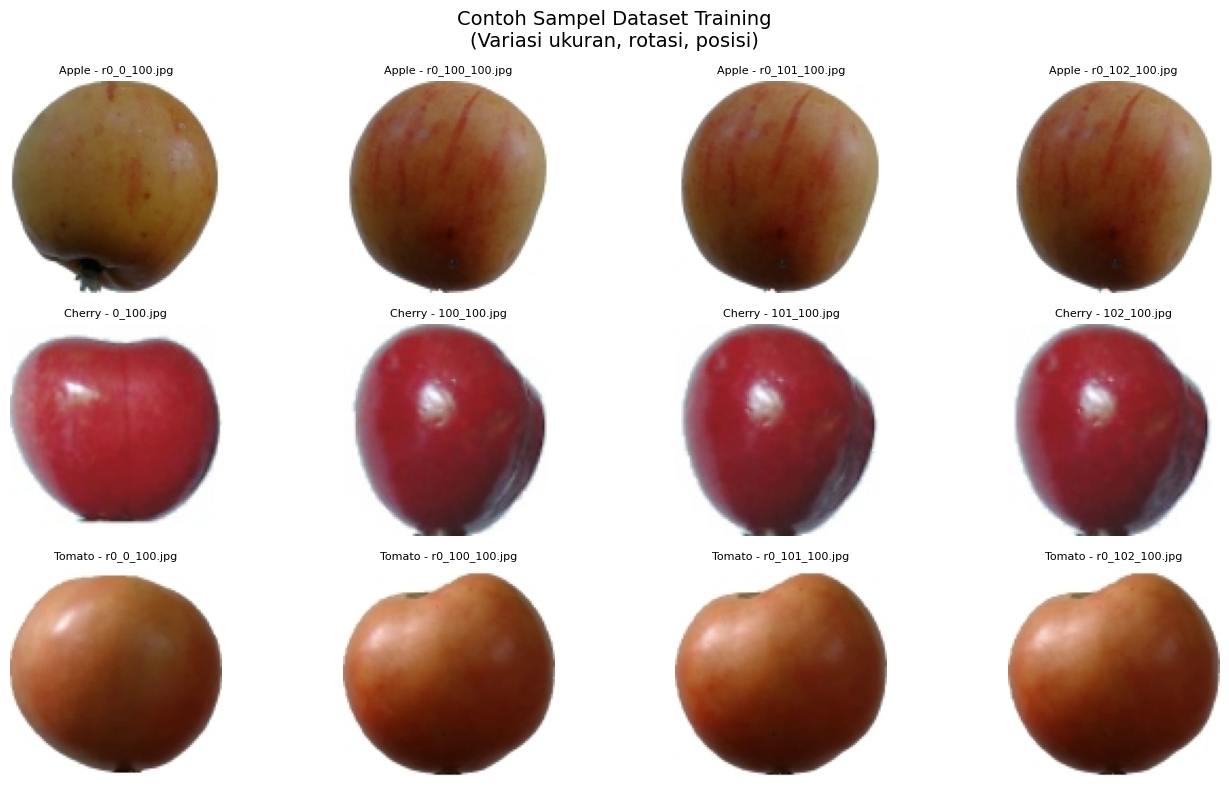

In [68]:
# Cek minimal 6 gambar per kelas
for cls, imgs in dataset.items():
    if len(imgs) < 6:
        print(f"{cls} hanya memiliki {len(imgs)} gambar, disarankan 6-10!!.")

# Visualisasi 4 sampel pertama dari setiap kelas (untuk melihat variasi)
fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(14, 8))
for row, cls in enumerate(CLASS_NAMES):
    for col in range(4):
        ax = axes[row, col]
        if col < len(dataset[cls]):
            img, fname = dataset[cls][col]
            # Konversi BGR ke RGB untuk tampilan yang benar
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{cls} - {fname}", fontsize=8)
        else:
            ax.set_title("Tidak ada gambar")
        ax.axis('off')
plt.suptitle("Contoh Sampel Dataset Training\n(Variasi ukuran, rotasi, posisi)", fontsize=14)
plt.tight_layout()
plt.show()

In [69]:
# Step 2: Ekstraksi Properti Region Dasar
def preprocess_get_contour(img_bgr):
    """Konversi ke grayscale, threshold Otsu, dan ambil kontur terbesar."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Threshold Otsu untuk biner terbalik (objek putih, background hitam)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Morph close untuk menutup lubang kecil
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Cari kontur
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    # Ambil kontur terbesar berdasarkan luas
    largest = max(contours, key=cv2.contourArea)
    return largest

def compute_region_properties(contour):
    """Menghitung properti region dari kontur."""
    # Luas dan perimeter
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    # Centroid dari momen
    M = cv2.moments(contour)
    if M['m00'] != 0:
        cx = M['m10'] / M['m00']
        cy = M['m01'] / M['m00']
    else:
        cx = cy = 0
    # Bounding box
    x, y, w, h = cv2.boundingRect(contour)
    # Convex hull
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    # Properti turunan
    aspect_ratio = w / h if h != 0 else 0
    extent = area / (w * h) if (w * h) != 0 else 0
    solidity = area / hull_area if hull_area != 0 else 0
    return {
        'area': area,
        'perimeter': perimeter,
        'centroid_x': cx,
        'centroid_y': cy,
        'bbox_x': x, 'bbox_y': y, 'bbox_w': w, 'bbox_h': h,
        'convex_hull_area': hull_area,
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'solidity': solidity,
        'contour': contour,
        'hull': hull,
        'bbox': (x, y, w, h)
    }

Tabel Properti Region (10 sampel pertama):


,area,perimeter,centroid_x,centroid_y,bbox_x,bbox_y,bbox_w,bbox_h,convex_hull_area,aspect_ratio,extent,solidity,contour,hull,bbox,class,filename
0,7455.5,336.835567,49.243690,48.230099,0,0,100,100,7635.5,1.00,0.745550,0.976426,"[[[33, 0]], [[33, 1]], [[33, 2]], [[32, 3]], [...","[[[68, 0]], [[81, 10]], [[84, 13]], [[88, 18]]...","(0, 0, 100, 100)",Apple,r0_0_100.jpg
1,7160.5,322.835567,48.702628,48.778437,3,0,93,100,7263.0,0.93,0.769946,0.985887,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[79, 10]], [[88, 19]], [[90, 22]]...","(3, 0, 93, 100)",Apple,r0_100_100.jpg
2,7160.0,322.249781,48.785964,48.763594,3,0,93,100,7253.0,0.93,0.769892,0.987178,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[79, 10]], [[88, 19]], [[92, 25]]...","(3, 0, 93, 100)",Apple,r0_101_100.jpg
3,7069.5,320.835567,49.331872,48.714831,4,0,92,100,7162.0,0.92,0.768424,0.987085,"[[[35, 0]], [[35, 1]], [[35, 2]], [[34, 3]], [...","[[[64, 0]], [[79, 10]], [[89, 20]], [[91, 23]]...","(4, 0, 92, 100)",Apple,r0_102_100.jpg
4,7060.5,320.835567,49.321601,48.687982,4,0,92,100,7158.5,0.92,0.767446,0.986310,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[79, 10]], [[89, 20]], [[91, 23]]...","(4, 0, 92, 100)",Apple,r0_103_100.jpg
5,7076.0,321.421354,49.345676,48.655620,4,0,92,100,7178.5,0.92,0.769130,0.985721,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[79, 10]], [[86, 16]], [[90, 21]]...","(4, 0, 92, 100)",Apple,r0_104_100.jpg
6,7079.0,321.421354,49.480035,48.643759,4,0,92,100,7177.0,0.92,0.769457,0.986345,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[78, 9]], [[83, 13]], [[88, 18]],...","(4, 0, 92, 100)",Apple,r0_105_100.jpg
7,7066.0,321.421354,49.450066,48.649542,4,0,92,100,7166.5,0.92,0.768043,0.985976,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[64, 0]], [[79, 10]], [[83, 13]], [[87, 17]]...","(4, 0, 92, 100)",Apple,r0_106_100.jpg
8,6989.0,319.421354,48.942362,48.745052,4,0,91,100,7087.5,0.91,0.768022,0.986102,"[[[34, 0]], [[34, 1]], [[34, 2]], [[33, 3]], [...","[[[63, 0]], [[78, 10]], [[83, 14]], [[86, 17]]...","(4, 0, 91, 100)",Apple,r0_107_100.jpg
9,7022.0,319.421354,48.957087,48.700109,4,0,91,100,7116.5,0.91,0.771648,0.986721,"[[[33, 0]], [[33, 1]], [[33, 2]], [[32, 3]], [...","[[[63, 0]], [[74, 7]], [[77, 9]], [[81, 12]], ...","(4, 0, 91, 100)",Apple,r0_108_100.jpg


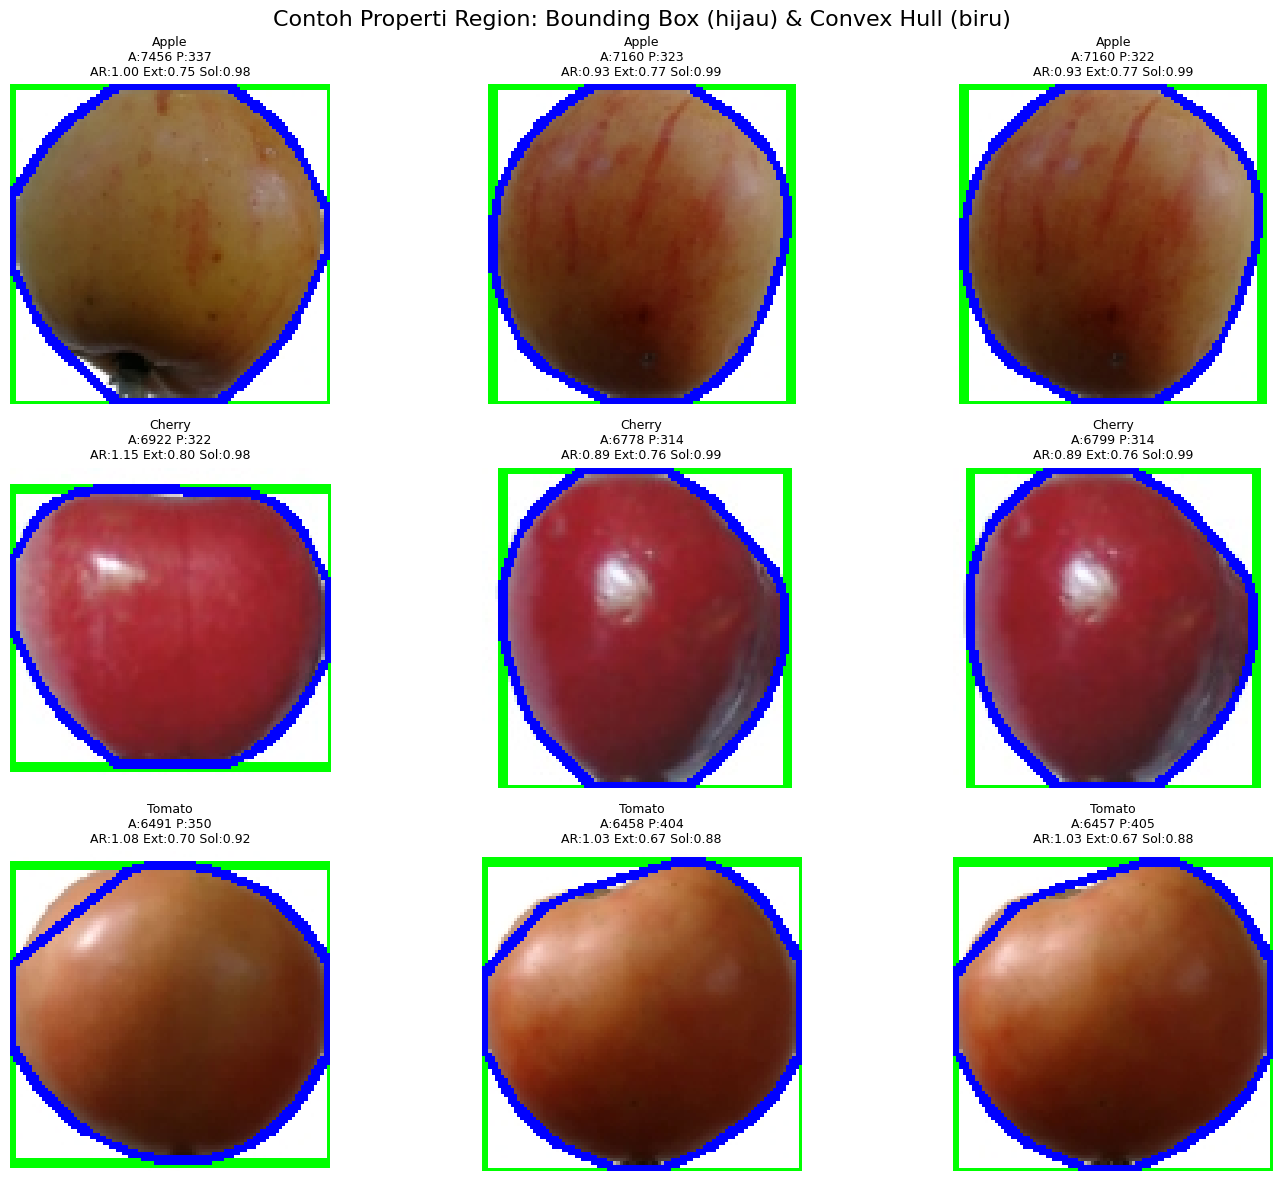

In [70]:
# Proses semua gambar training dan kumpulkan properti
all_properties = []  # list of dict
for cls in CLASS_NAMES:
    for img, fname in dataset[cls]:
        cnt = preprocess_get_contour(img)
        if cnt is not None:
            props = compute_region_properties(cnt)
            props['class'] = cls
            props['filename'] = fname
            all_properties.append(props)
        else:
            print(f"Tidak ada kontur di {cls}/{fname}")

# Buat DataFrame
df_props = pd.DataFrame(all_properties)

# Tampilkan beberapa baris pertama (10)
print("Tabel Properti Region (10 sampel pertama):")
display(df_props.head(10))

# Visualisasi contoh dengan bounding box & convex hull
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(15, 4*len(CLASS_NAMES)))
for row, cls in enumerate(CLASS_NAMES):
    # Ambil 3 sampel pertama dari DataFrame yang kelasnya sesuai
    samples = df_props[df_props['class'] == cls].head(3)
    for col, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        # Dapatkan gambar asli (ambil dari dataset)
        # cari gambar asli berdasarkan filename
        orig_img = None
        for img, fname in dataset[cls]:
            if fname == sample['filename']:
                orig_img = img
                break
        if orig_img is None:
            continue
        # Gambar bounding box (hijau) dan convex hull (biru)
        img_draw = orig_img.copy()
        cnt = sample['contour']
        hull = sample['hull']
        x, y, w, h = sample['bbox']
        cv2.rectangle(img_draw, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.drawContours(img_draw, [hull], -1, (255,0,0), 2)
        ax.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{cls}\nA:{sample['area']:.0f} P:{sample['perimeter']:.0f}\n"
                     f"AR:{sample['aspect_ratio']:.2f} Ext:{sample['extent']:.2f} Sol:{sample['solidity']:.2f}",
                     fontsize=9)
        ax.axis('off')
plt.suptitle("Contoh Properti Region: Bounding Box (hijau) & Convex Hull (biru)", fontsize=16)
plt.tight_layout()
plt.show()

In [71]:
# Step 3: Implementasi Moments (Spatial, Central, Hu)
# Pastikan df_props dari Step 2 memiliki kolom 'contour'
if 'contour' not in df_props.columns:
    raise Exception("Kolom 'contour' tidak ditemukan. Pastikan Step 2 menyimpan kontur di DataFrame.")

# Inisialisasi list untuk setiap momen
m00_vals, m10_vals, m01_vals = [], [], []
mu20_vals, mu02_vals, mu11_vals = [], [], []
hu1_vals, hu2_vals, hu3_vals, hu4_vals, hu5_vals, hu6_vals, hu7_vals = [], [], [], [], [], [], []

# Loop melalui setiap kontur di DataFrame
for cnt in df_props['contour']:
    M = cv2.moments(cnt)
    
    # Spatial moments
    m00_vals.append(M['m00'])
    m10_vals.append(M['m10'])
    m01_vals.append(M['m01'])
    
    # Central moments
    mu20_vals.append(M['mu20'])
    mu02_vals.append(M['mu02'])
    mu11_vals.append(M['mu11'])
    
    # Hu moments (7 invariant)
    hu = cv2.HuMoments(M).flatten()
    hu1_vals.append(hu[0])
    hu2_vals.append(hu[1])
    hu3_vals.append(hu[2])
    hu4_vals.append(hu[3])
    hu5_vals.append(hu[4])
    hu6_vals.append(hu[5])
    hu7_vals.append(hu[6])

# Tambahkan semua kolom momen ke DataFrame
df_props['m00'] = m00_vals
df_props['m10'] = m10_vals
df_props['m01'] = m01_vals
df_props['mu20'] = mu20_vals
df_props['mu02'] = mu02_vals
df_props['mu11'] = mu11_vals
df_props['hu1'] = hu1_vals
df_props['hu2'] = hu2_vals
df_props['hu3'] = hu3_vals
df_props['hu4'] = hu4_vals
df_props['hu5'] = hu5_vals
df_props['hu6'] = hu6_vals
df_props['hu7'] = hu7_vals

Tabel Momen Spasial, Sentral, dan Hu (10 sampel pertama):


,class,filename,m00,m10,m01,mu20,mu02,mu11,hu1,hu2,hu3,hu4,hu5
0,Apple,r0_0_100.jpg,7455.5,367136.333333,359579.500000,4.279577e+06,4.602972e+06,-3467.675779,0.159803,0.000034,0.000020,4.744277e-08,4.468280e-14
1,Apple,r0_100_100.jpg,7160.5,348735.166667,349278.000000,3.736313e+06,4.474934e+06,-124374.489261,0.160148,0.000231,0.000008,4.190459e-08,-1.193202e-14
2,Apple,r0_101_100.jpg,7160.0,349307.500000,349147.333333,3.736573e+06,4.473271e+06,-122445.042132,0.160143,0.000229,0.000008,4.065253e-08,-1.122158e-14
3,Apple,r0_102_100.jpg,7069.5,348751.666667,344389.500000,3.602538e+06,4.409644e+06,-120286.738410,0.160315,0.000284,0.000008,4.823753e-08,-1.007425e-14
4,Apple,r0_103_100.jpg,7060.5,348235.166667,343761.500000,3.585064e+06,4.408280e+06,-111902.220455,0.160346,0.000293,0.000009,4.884176e-08,-1.118374e-14
5,Apple,r0_104_100.jpg,7076.0,349170.000000,344287.166667,3.606151e+06,4.420890e+06,-107124.146363,0.160317,0.000283,0.000009,5.015937e-08,-1.283675e-14
6,Apple,r0_105_100.jpg,7079.0,350269.166667,344349.166667,3.606465e+06,4.427597e+06,-103591.932127,0.160321,0.000286,0.000010,5.065097e-08,-1.479378e-14
7,Apple,r0_106_100.jpg,7066.0,349414.166667,343757.666667,3.586878e+06,4.419027e+06,-96263.903120,0.160348,0.000293,0.000010,5.203364e-08,-1.515867e-14
8,Apple,r0_107_100.jpg,6989.0,342058.166667,340679.166667,3.472844e+06,4.368274e+06,-88788.034988,0.160527,0.000349,0.000010,6.185104e-08,-1.264152e-14
9,Apple,r0_108_100.jpg,7022.0,343776.666667,341972.166667,3.501958e+06,4.413308e+06,-79768.783767,0.160525,0.000352,0.000010,5.734932e-08,-1.150615e-14


C:\Users\Pongo\AppData\Local\Temp\ipykernel_15384\1062538014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=CLASS_NAMES)
C:\Users\Pongo\AppData\Local\Temp\ipykernel_15384\1062538014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=CLASS_NAMES)
C:\Users\Pongo\AppData\Local\Temp\ipykernel_15384\1062538014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=CLASS_NAMES)
C:\Users\Pongo\AppData\Local\Temp\ipykernel_15384\1062538014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been

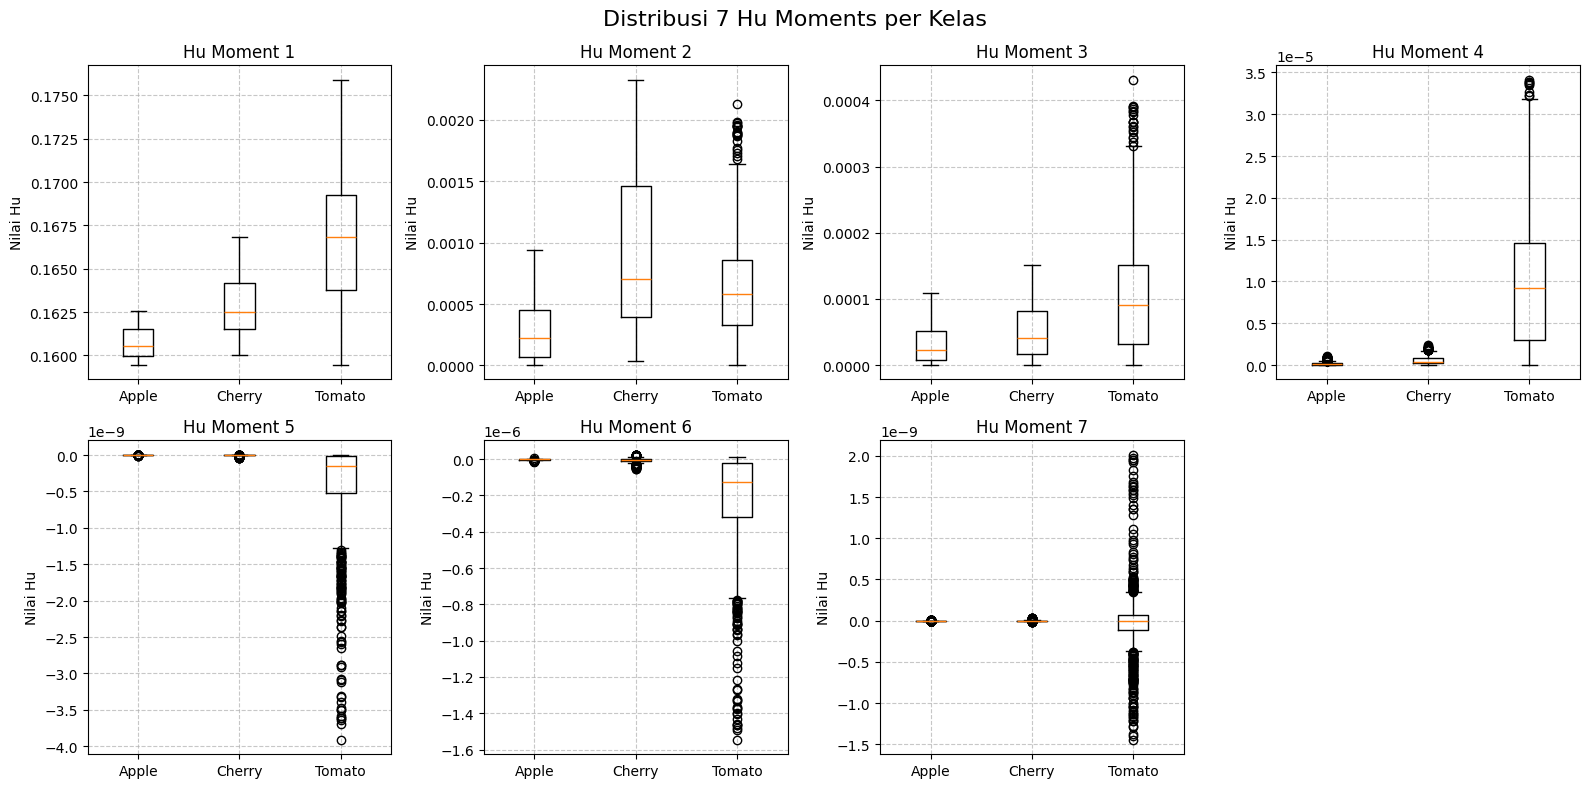

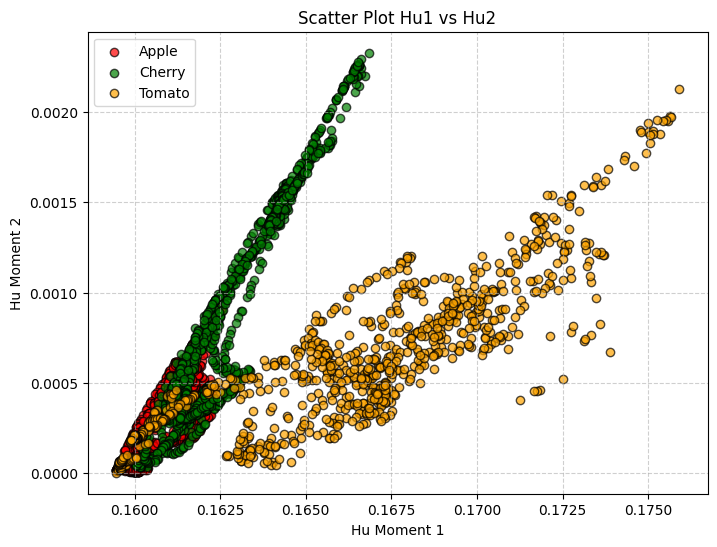

Momen telah dihitung dan ditambahkan ke DataFrame.


In [72]:
# Tampilkan tabel momen (10 sampel pertama)
print("Tabel Momen Spasial, Sentral, dan Hu (10 sampel pertama):")
display(df_props[['class','filename','m00','m10','m01','mu20','mu02','mu11','hu1','hu2','hu3','hu4','hu5']].head(10))

# Visualisasi Distribusi Hu Moments per Kelas (Boxplot)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, hu_col in enumerate(['hu1','hu2','hu3','hu4','hu5','hu6','hu7']):
    ax = axes[i]
    data_per_class = [df_props[df_props['class'] == cls][hu_col] for cls in CLASS_NAMES]
    ax.boxplot(data_per_class, labels=CLASS_NAMES)
    ax.set_title(f'Hu Moment {i+1}')
    ax.set_ylabel('Nilai Hu')
    ax.grid(True, linestyle='--', alpha=0.7)
# Sembunyikan subplot ke-8 (kosong)
axes[7].set_visible(False)
plt.suptitle('Distribusi 7 Hu Moments per Kelas', fontsize=16)
plt.tight_layout()
plt.show()

# Scatter Plot: Hu1 vs Hu2 untuk melihat pemisahan kelas
plt.figure(figsize=(8, 6))
colors = {'Apple': 'red', 'Cherry': 'green', 'Tomato': 'orange'}
for cls in CLASS_NAMES:
    subset = df_props[df_props['class'] == cls]
    plt.scatter(subset['hu1'], subset['hu2'], c=colors[cls], label=cls, alpha=0.7, edgecolors='k')
plt.xlabel('Hu Moment 1')
plt.ylabel('Hu Moment 2')
plt.title('Scatter Plot Hu1 vs Hu2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Momen telah dihitung dan ditambahkan ke DataFrame.")

In [73]:
# Step 4: Representasi Batas – Chain Codes & Polygonal Approximation
# 4.1 Chain code 4-arah
def chain_code_4(contour):
    """
    Menghasilkan 4-directional chain code (0: kanan, 1: atas, 2: kiri, 3: bawah).
    """
    dx = np.diff(contour[:, 0, 0])
    dy = np.diff(contour[:, 0, 1])
    code = []
    for dx_, dy_ in zip(dx, dy):
        if dx_ == 1 and dy_ == 0:
            code.append(0)   # kanan
        elif dx_ == 0 and dy_ == -1:
            code.append(1)   # atas
        elif dx_ == -1 and dy_ == 0:
            code.append(2)   # kiri
        elif dx_ == 0 and dy_ == 1:
            code.append(3)   # bawah
    return np.array(code)

In [74]:
# 4.2 Chain code 8-arah
def chain_code_8(contour):
    """
    Menghasilkan 8-directional chain code.
    Arah: 0=E, 1=NE, 2=N, 3=NW, 4=W, 5=SW, 6=S, 7=SE
    """
    dx = np.diff(contour[:, 0, 0])
    dy = np.diff(contour[:, 0, 1])
    lut = {
        (1,0): 0,   # E
        (1,-1): 1,  # NE
        (0,-1): 2,  # N
        (-1,-1): 3, # NW
        (-1,0): 4,  # W
        (-1,1): 5,  # SW
        (0,1): 6,   # S
        (1,1): 7    # SE
    }
    code = [lut.get((dx_, dy_), -1) for dx_, dy_ in zip(dx, dy)]
    return np.array(code)

In [75]:
# 4.3 Normalisasi rotasi untuk chain code
def normalize_chain_code(chain):
    """
    Normalisasi rotasi: pilih titik awal yang menghasilkan urutan kode 
    dengan nilai numerik terkecil (jika dianggap sebagai bilangan bulat).
    """
    if len(chain) == 0:
        return chain
    n = len(chain)
    min_chain = chain
    min_val = int(''.join(map(str, chain)))
    for i in range(1, n):
        rot = np.concatenate([chain[i:], chain[:i]])
        val = int(''.join(map(str, rot)))
        if val < min_val:
            min_val = val
            min_chain = rot
    return min_chain

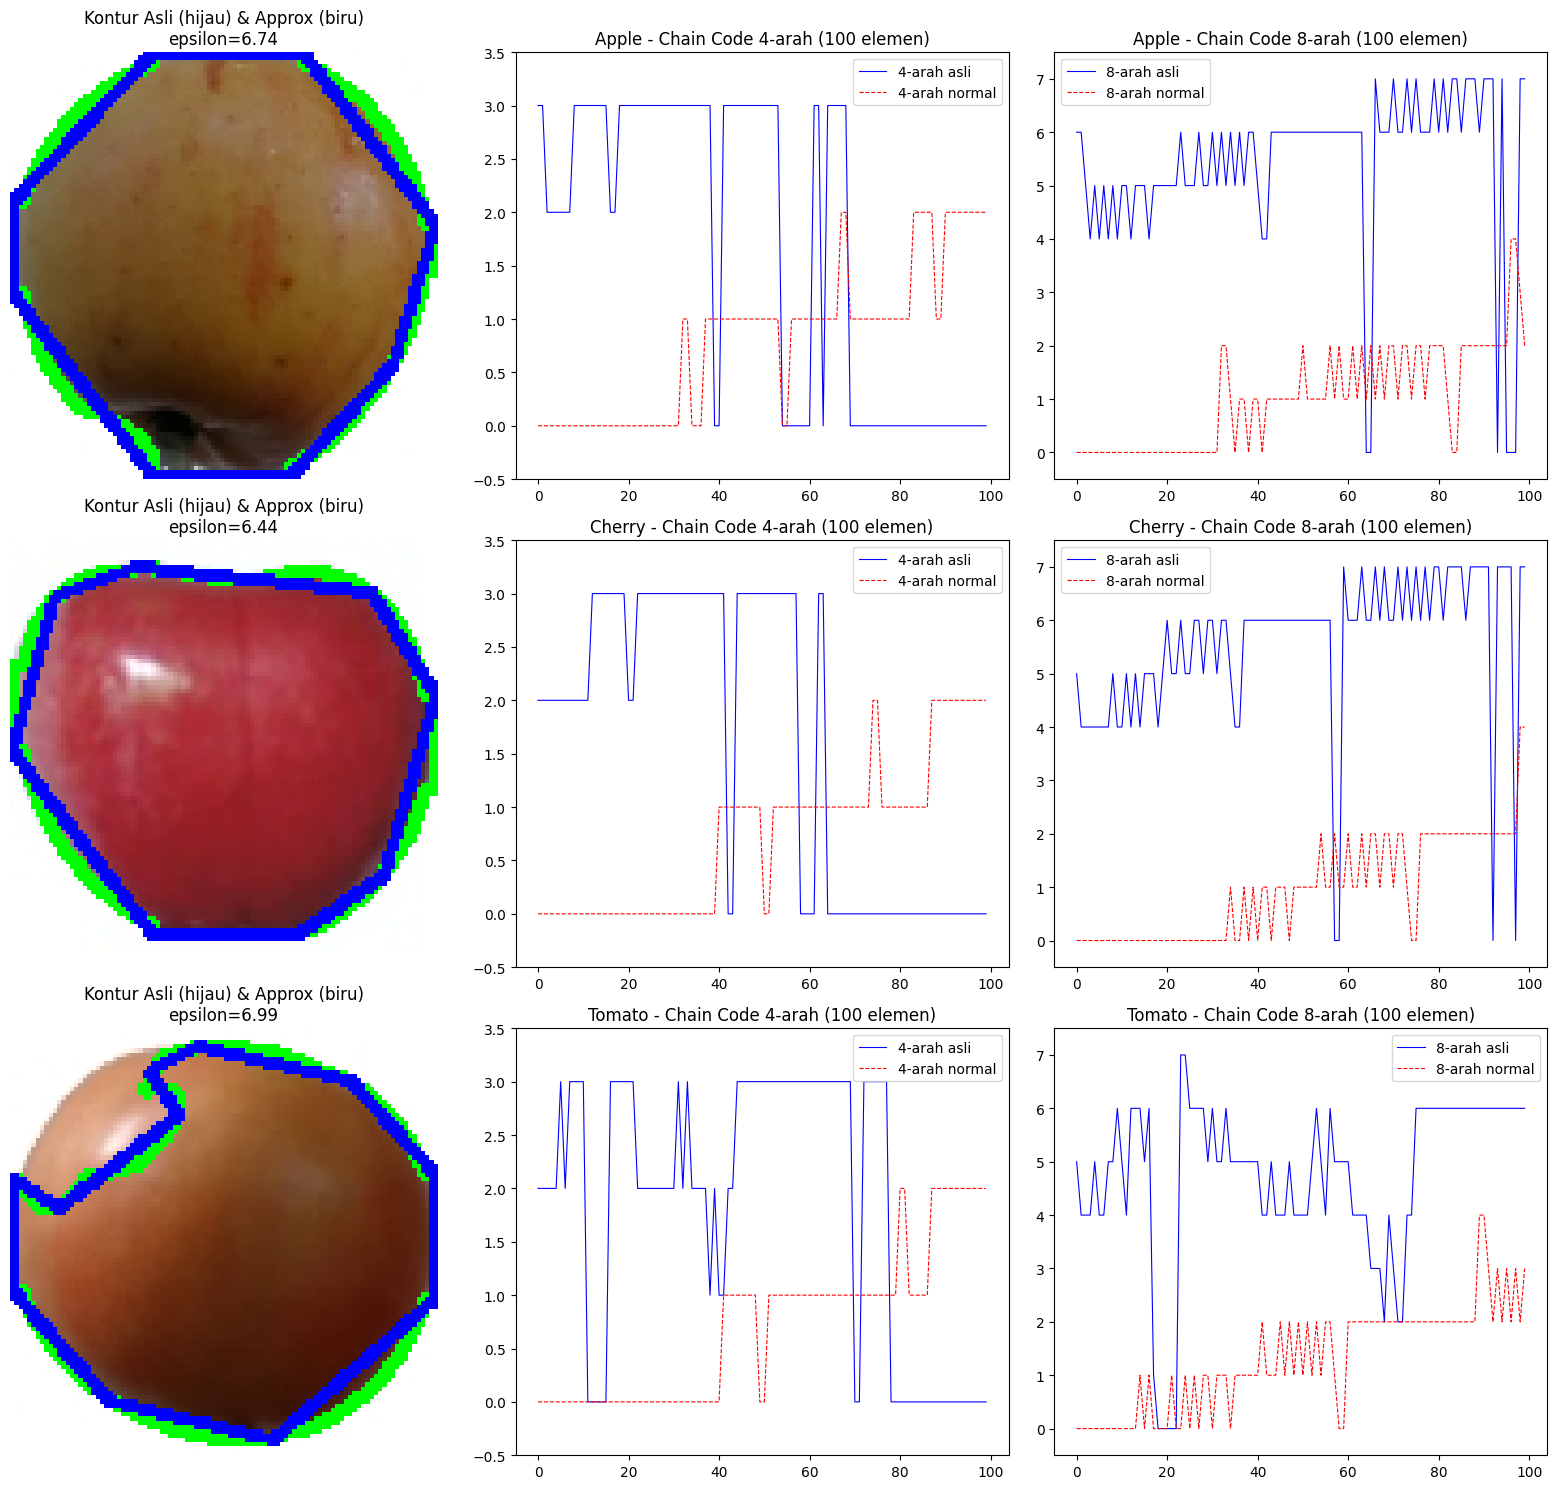

Informasi Chain Code dan Approx:

Apple (r0_0_100.jpg)
- Kontur asli: 295 titik
  Chain code 4-arah (asli): 193 elemen, contoh: [3 3 2 2 2 2 2 2 3 3 3 3 3 3 3 3 2 2 3 3]...
  Chain code 4-arah (normal): 193 elemen, contoh: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...
  Chain code 8-arah (asli): 294 elemen, contoh: [6 6 5 4 5 4 5 4 5 4 5 5 4 5 5 5 4 5 5 5]...
  Aproksimasi poligon: 8 titik (epsilon=6.74)

Cherry (0_100.jpg)
- Kontur asli: 285 titik
  Chain code 4-arah (asli): 195 elemen, contoh: [2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3]...
  Chain code 4-arah (normal): 195 elemen, contoh: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...
  Chain code 8-arah (asli): 284 elemen, contoh: [5 4 4 4 4 4 4 4 5 4 4 5 4 5 4 5 5 5 4 5]...
  Aproksimasi poligon: 8 titik (epsilon=6.44)

Tomato (r0_0_100.jpg)
- Kontur asli: 304 titik
  Chain code 4-arah (asli): 193 elemen, contoh: [2 2 2 2 2 3 2 3 3 3 3 0 0 0 0 0 3 3 3 3]...
  Chain code 4-arah (normal): 193 elemen, contoh: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [76]:
# 4.4 Polygonal approximation (Douglas-Peucker)
def poly_approx(contour, epsilon_ratio=0.02):
    """
    Mengaproksimasi kontur dengan polyline menggunakan Douglas-Peucker.
    epsilon = epsilon_ratio * perimeter
    """
    perimeter = cv2.arcLength(contour, True)
    epsilon = epsilon_ratio * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return approx, epsilon

# Demonstrasi pada satu sampel per kelas
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(16, 5*len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    # Ambil satu sampel pertama
    sample = df_props[df_props['class'] == cls].iloc[0]
    cnt = sample['contour']
    
    # --- Chain codes ---
    cc4 = chain_code_4(cnt)
    cc8 = chain_code_8(cnt)
    cc4_norm = normalize_chain_code(cc4)
    cc8_norm = normalize_chain_code(cc8)
    
    # --- Polygonal approximation ---
    approx, eps = poly_approx(cnt, epsilon_ratio=0.02)
    
    # Plot 1: Kontur asli & aproksimasi poligon
    ax0 = axes[row, 0]
    orig_img = None
    for img, fname in dataset[cls]:
        if fname == sample['filename']:
            orig_img = img.copy()
            break
    if orig_img is not None:
        cv2.drawContours(orig_img, [cnt], -1, (0,255,0), 2)          # asli hijau
        cv2.drawContours(orig_img, [approx], -1, (255,0,0), 2)       # approx biru
        ax0.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
        ax0.set_title(f"Kontur Asli (hijau) & Approx (biru)\nepsilon={eps:.2f}")
    ax0.axis('off')
    
    # Plot 2: Chain code 4-arah & normalisasi (sebagian)
    ax1 = axes[row, 1]
    ax1.plot(cc4[:100], 'b-', linewidth=0.8, label='4-arah asli')
    ax1.plot(cc4_norm[:100], 'r--', linewidth=0.8, label='4-arah normal')
    ax1.set_title(f"{cls} - Chain Code 4-arah (100 elemen)")
    ax1.legend()
    ax1.set_ylim(-0.5, 3.5)
    
    # Plot 3: Chain code 8-arah & normalisasi (sebagian)
    ax2 = axes[row, 2]
    ax2.plot(cc8[:100], 'b-', linewidth=0.8, label='8-arah asli')
    ax2.plot(cc8_norm[:100], 'r--', linewidth=0.8, label='8-arah normal')
    ax2.set_title(f"{cls} - Chain Code 8-arah (100 elemen)")
    ax2.legend()
    ax2.set_ylim(-0.5, 7.5)

plt.tight_layout()
plt.show()

# Tampilkan panjang chain code dan contoh nilai numerik
print("Informasi Chain Code dan Approx:")
for cls in CLASS_NAMES:
    sample = df_props[df_props['class'] == cls].iloc[0]
    cnt = sample['contour']
    cc4 = chain_code_4(cnt)
    cc8 = chain_code_8(cnt)
    cc4_norm = normalize_chain_code(cc4)
    approx, eps = poly_approx(cnt)
    
    print(f"\n{cls} ({sample['filename']})")
    print(f"- Kontur asli: {len(cnt)} titik")
    print(f"  Chain code 4-arah (asli): {len(cc4)} elemen, contoh: {cc4[:20]}...")
    print(f"  Chain code 4-arah (normal): {len(cc4_norm)} elemen, contoh: {cc4_norm[:20]}...")
    print(f"  Chain code 8-arah (asli): {len(cc8)} elemen, contoh: {cc8[:20]}...")
    print(f"  Aproksimasi poligon: {len(approx)} titik (epsilon={eps:.2f})")

In [77]:
# Step 5: Fourier Descriptors
# Fungsi bantu: resample kontur menjadi N titik seragam
def resample_contour(contour, num_points=128):
    """Resample kontur menjadi `num_points` titik yang berjarak seragam sepanjang perimeter."""
    # Hitung total perimeter
    dist_total = cv2.arcLength(contour, True)
    # Jarak antar titik sampling
    step = dist_total / num_points
    sampled = []
    # Mulai dari titik pertama
    px, py = contour[0][0]
    sampled.append([px, py])
    remaining = step
    i = 1
    while len(sampled) < num_points:
        # Ambil segmen berikutnya
        x1, y1 = contour[i-1][0]
        x2, y2 = contour[i][0]
        seg_len = np.linalg.norm([x2-x1, y2-y1])
        if seg_len < remaining:
            remaining -= seg_len
            i += 1
            if i == len(contour):
                # Kembali ke titik awal (kontur tertutup)
                i = 0  # Bungkus
        else:
            # Interpolasi di segmen
            t = remaining / seg_len
            x_new = x1 + t * (x2 - x1)
            y_new = y1 + t * (y2 - y1)
            sampled.append([x_new, y_new])
            # Update posisi pada segmen
            # Geser titik awal segmen ke titik baru
            contour = np.vstack([contour[i-1:], contour[:i-1]])  # Sulit, kita pakai cara lain
            # Lebih mudah pakai array
            # Saya gunakan ulang fungsi yg lebih sederhana:
            break
    # Agar sederhana, pakai pendekatan berbasis panjang kumulatif:
    return resample_contour2(contour, num_points)

In [78]:
# Step 5: Fourier Descriptors
# Fungsi bantu: resample kontur menjadi N titik seragam
def resample_contour(contour, num_points=128):
    """Resample kontur menjadi `num_points` titik yang berjarak seragam sepanjang perimeter."""
    # Hitung total perimeter
    dist_total = cv2.arcLength(contour, True)
    # Jarak antar titik sampling
    step = dist_total / num_points
    sampled = []
    # Mulai dari titik pertama
    px, py = contour[0][0]
    sampled.append([px, py])
    remaining = step
    i = 1
    while len(sampled) < num_points:
        # Ambil segmen berikutnya
        x1, y1 = contour[i-1][0]
        x2, y2 = contour[i][0]
        seg_len = np.linalg.norm([x2-x1, y2-y1])
        if seg_len < remaining:
            remaining -= seg_len
            i += 1
            if i == len(contour):
                # Kembali ke titik awal (kontur tertutup)
                i = 0  # Bungkus
        else:
            # Interpolasi di segmen
            t = remaining / seg_len
            x_new = x1 + t * (x2 - x1)
            y_new = y1 + t * (y2 - y1)
            sampled.append([x_new, y_new])
            # Update posisi pada segmen
            # Geser titik awal segmen ke titik baru
            contour = np.vstack([contour[i-1:], contour[:i-1]])  # Sulit, kita pakai cara lain
            # Lebih mudah pakai array
            # Saya gunakan ulang fungsi yg lebih sederhana:
            break
    # Agar sederhana, pakai pendekatan berbasis panjang kumulatif:
    return resample_contour2(contour, num_points)

def resample_contour2(contour, num_points=128):
    """Resample dengan interpolasi linear berdasarkan panjang kumulatif."""
    pts = contour.reshape(-1, 2).astype(np.float64)
    # Hitung jarak kumulatif
    diffs = np.diff(pts, axis=0)
    seg_lens = np.linalg.norm(diffs, axis=1)
    cumlen = np.insert(np.cumsum(seg_lens), 0, 0)
    total = cumlen[-1]
    # Buat array jarak yang diinginkan
    dist_req = np.linspace(0, total, num_points+1)[:-1]
    # Interpolasi
    xs = np.interp(dist_req, cumlen, pts[:, 0])
    ys = np.interp(dist_req, cumlen, pts[:, 1])
    return np.column_stack([xs, ys])

# Fourier descriptors dengan normalisasi
def fourier_descriptors(contour, num_points=128, num_descriptors=None):
    """
    Menghitung Fourier descriptors yang ternormalisasi.
    Return vektor magnitudo dari koefisien positif, tanpa DC, 
    dinormalisasi terhadap translasi, skala, dan rotasi.
    """
    # Resample
    pts = resample_contour2(contour, num_points)
    # Representasi kompleks (x + iy)
    z = pts[:, 0] + 1j * pts[:, 1]
    # Translasi: hilangkan DC (atau pusatkan ke 0)
    z_centered = z - np.mean(z)
    # FFT
    fft = np.fft.fft(z_centered)
    # Ambil setengah (frekuensi positif) karena simetri untuk sinyal real
    n = len(fft)
    half = n // 2
    # Untuk bentuk tertutup, koefisien dari 1 hingga half (abaikan DC di indeks 0)
    descriptors = fft[1:half]  # indeks 1..half-1
    # Normalisasi skala dan rotasi:
    # modulus descriptor pertama (indeks 0) harus non-zero untuk normalisasi
    if len(descriptors) > 0 and np.abs(descriptors[0]) > 1e-10:
        descriptors = descriptors / np.abs(descriptors[0])  # normalisasi skala
    # Ambil magnitudo saja -> invarian terhadap rotasi
    mag = np.abs(descriptors)
    # Jika num_descriptors ditentukan, potong/pad
    if num_descriptors is not None:
        if len(mag) > num_descriptors:
            mag = mag[:num_descriptors]
        else:
            mag = np.pad(mag, (0, num_descriptors - len(mag)), 'constant')
    return mag

# Rekonstruksi dari kompleks FFT (untuk visualisasi)
def reconstruct_contour(contour, num_descriptors, num_points=128):
    """
    Rekonstruksi kontur dari `num_descriptors` koefisien Fourier pertama.
    Koefisien DC tidak diikutsertakan? Kita tetap masukkan agar posisi benar.
    """
    pts = resample_contour2(contour, num_points)
    z = pts[:, 0] + 1j * pts[:, 1]
    z_centered = z - np.mean(z)
    fft = np.fft.fft(z_centered)
    # Pertahankan koefisien DC (indeks 0) dan sejumlah koefisien positif/negatif.
    # Karena sinyal real, kita perlu mempertahankan pasangan konjugat.
    n = len(fft)
    # Indeks yang akan dipertahankan:
    # Simpan DC (0), lalu koefisien 1..K, dan cerminannya di n-1..n-K.
    keep = np.zeros(n, dtype=complex)
    K = num_descriptors
    if K > n//2 - 1:
        K = n//2 - 1
    keep[0] = fft[0]  # DC
    keep[1:K+1] = fft[1:K+1]           # frekuensi positif 1..K
    keep[n-K:n] = fft[n-K:n]           # pasangan negatif (n-K..n-1)
    # Inverse FFT
    z_rec = np.fft.ifft(keep)
    # Kembalikan rata-rata
    rec_pts = np.column_stack((z_rec.real + np.mean(pts[:,0]), z_rec.imag + np.mean(pts[:,1])))
    return rec_pts

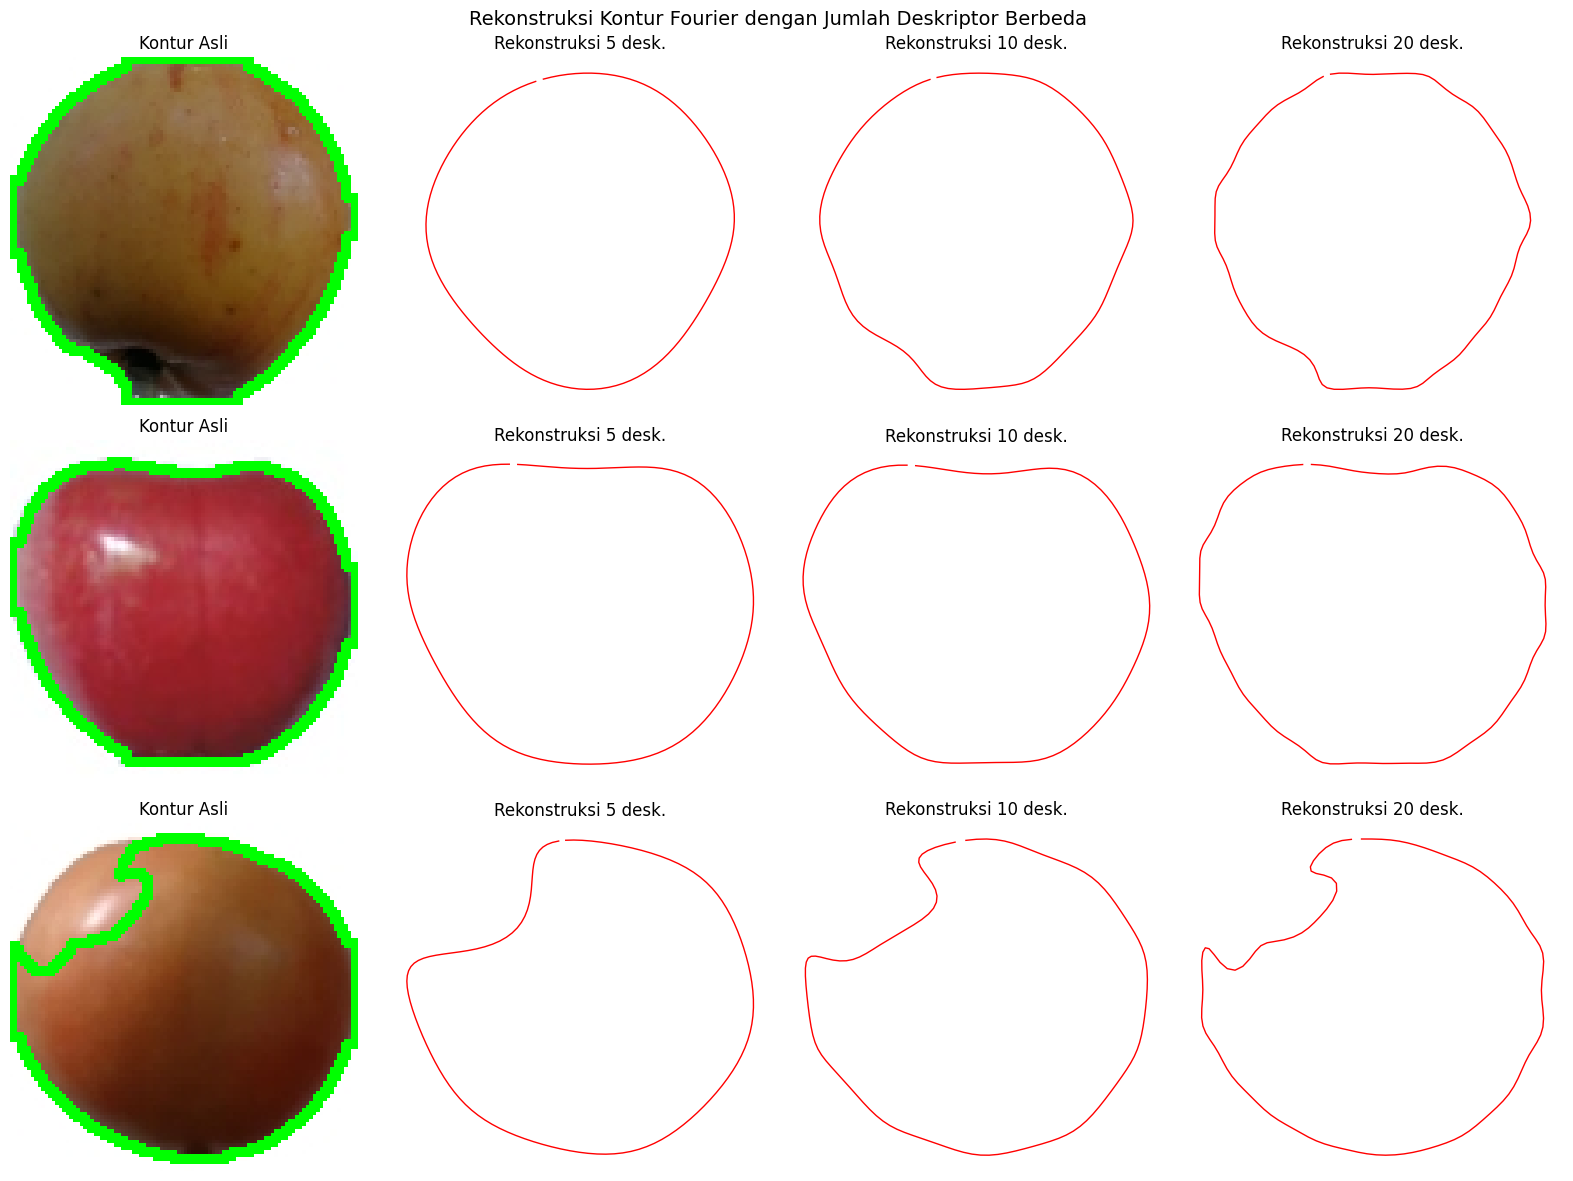

Fourier Descriptors (10 koefisien pertama) – 5 sampel pertama:


,class,filename,fd_features
0,Apple,r0_0_100.jpg,"[1.0000000000000002, 1.507543048019036, 1.2268..."
1,Apple,r0_100_100.jpg,"[0.9999999999999999, 0.2916985061320922, 0.254..."
2,Apple,r0_101_100.jpg,"[1.0, 0.2754441375949484, 0.25758287643800026,..."
3,Apple,r0_102_100.jpg,"[1.0, 0.25436747952999245, 0.2469623131004763,..."
4,Apple,r0_103_100.jpg,"[1.0000000000000002, 0.26309301074572766, 0.23..."



Fourier descriptors berhasil dihitung.


In [79]:
# Demo: satu gambar per kelas
fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(16, 4*len(CLASS_NAMES)))
for row, cls in enumerate(CLASS_NAMES):
    sample = df_props[df_props['class'] == cls].iloc[0]
    cnt = sample['contour']
    
    # Original contour
    ax0 = axes[row, 0]
    orig_img = None
    for img, fname in dataset[cls]:
        if fname == sample['filename']:
            orig_img = img.copy()
            break
    if orig_img is not None:
        cv2.drawContours(orig_img, [cnt], -1, (0,255,0), 2)
        ax0.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
        ax0.set_title("Kontur Asli")
    ax0.axis('off')
    
    # Rekonstruksi dengan 5, 10, 20 descriptors
    for i, k in enumerate([5, 10, 20], start=1):
        ax = axes[row, i]
        rec_pts = reconstruct_contour(cnt, num_descriptors=k)
        ax.plot(rec_pts[:,0], rec_pts[:,1], 'r-', linewidth=1)
        # Untuk menampilkan dalam gambar, buat canvas kosong
        ax.set_title(f"Rekonstruksi {k} desk.")
        ax.set_aspect('equal')
        ax.invert_yaxis()  # karena opencv menganggap y menurun
        ax.axis('off')
plt.suptitle("Rekonstruksi Kontur Fourier dengan Jumlah Deskriptor Berbeda", fontsize=14)
plt.tight_layout()
plt.show()

# Hitung dan simpan Fourier descriptors feature (misal 10 koefisien)
fd_list = []
for cnt in df_props['contour']:
    fd = fourier_descriptors(cnt, num_points=128, num_descriptors=10)
    fd_list.append(fd)

df_props['fd_features'] = fd_list

# Tampilkan contoh nilai
print("Fourier Descriptors (10 koefisien pertama) – 5 sampel pertama:")
display(df_props[['class','filename','fd_features']].head(5))

print("\nFourier descriptors berhasil dihitung.")

In [80]:
# Step 6: Klasifikasi dan Evaluasi
# 6.1 Persiapkan data fitur dari TRAINING set (df_props)
# Pilih 3 deskriptor dari tiap kategori:
# - Region: area, aspect_ratio, solidity
# - Moments: hu1, hu2, hu3 (3 momen pertama)
# - Fourier: 3 koefisien pertama dari fd_features (fd1, fd2, fd3)

# Ambil fitur dari df_props
X_train_region = df_props[['area', 'aspect_ratio', 'solidity']].values
X_train_moments = df_props[['hu1', 'hu2', 'hu3']].values
# Fourier: exploit fd_features kolom (list) -> ambil 3 elemen pertama
fd_stacked = np.vstack(df_props['fd_features'].values)
X_train_fourier = fd_stacked[:, :3]  # 3 koefisien pertama

# Label
y_train = df_props['class'].values

# Gabung semua fitur
X_train_all = np.hstack([X_train_region, X_train_moments, X_train_fourier])

print("Data training siap:")
print(f"-Region features: {X_train_region.shape}")
print(f"-Moments features: {X_train_moments.shape}")
print(f"-Fourier features: {X_train_fourier.shape}")
print(f"-All features: {X_train_all.shape}")

Data training siap:
-Region features: (2523, 3)
-Moments features: (2523, 3)
-Fourier features: (2523, 3)
-All features: (2523, 9)


In [81]:
# 6.2 Muat dan proses TEST set
TEST_DIR = Path('../dataset/Test')
test_dataset = {}
for cls in CLASS_NAMES:
    folder = TEST_DIR / cls
    if not folder.exists():
        print(f"⚠ Folder test {folder} tidak ditemukan!")
        continue
    images = []
    for img_path in folder.glob('*.jpg'):
        img = cv2.imread(str(img_path))
        if img is not None:
            images.append((img, img_path.name))
    test_dataset[cls] = images
    print(f"Test {cls}: {len(images)} gambar")

# Ekstrak fitur dari test set
test_props = []
for cls in CLASS_NAMES:
    for img, fname in test_dataset[cls]:
        cnt = preprocess_get_contour(img)
        if cnt is not None:
            # Properti region (sama seperti training)
            region = compute_region_properties(cnt)
            # Moments
            M = cv2.moments(cnt)
            hu = cv2.HuMoments(M).flatten()
            # Fourier
            fd = fourier_descriptors(cnt, num_points=128, num_descriptors=10)
            # Simpan
            test_props.append({
                'class': cls,
                'filename': fname,
                'area': region['area'],
                'aspect_ratio': region['aspect_ratio'],
                'solidity': region['solidity'],
                'hu1': hu[0], 'hu2': hu[1], 'hu3': hu[2],
                'fd1': fd[0], 'fd2': fd[1], 'fd3': fd[2]
            })

df_test = pd.DataFrame(test_props)
print(f"Test set berisi {len(df_test)} sampel.")

# Bentuk array fitur test
X_test_region = df_test[['area', 'aspect_ratio', 'solidity']].values
X_test_moments = df_test[['hu1', 'hu2', 'hu3']].values
X_test_fourier = df_test[['fd1', 'fd2', 'fd3']].values
X_test_all = np.hstack([X_test_region, X_test_moments, X_test_fourier])
y_test = df_test['class'].values

Test Apple: 630 gambar
Test Cherry: 984 gambar
Test Tomato: 931 gambar
Test set berisi 2545 sampel.


In [82]:
# 6.3 Classical k-NN (k=3) dan evaluasi berbagai kombinasi
knn = KNeighborsClassifier(n_neighbors=3)

# Daftar kombinasi yang akan diuji
combinations = {
    'Region': (X_train_region, X_test_region),
    'Moments': (X_train_moments, X_test_moments),
    'Fourier': (X_train_fourier, X_test_fourier),
    'Region+Moments': (np.hstack([X_train_region, X_train_moments]),
                      np.hstack([X_test_region, X_test_moments])),
    'Region+Fourier': (np.hstack([X_train_region, X_train_fourier]),
                      np.hstack([X_test_region, X_test_fourier])),
    'Moments+Fourier': (np.hstack([X_train_moments, X_train_fourier]),
                       np.hstack([X_test_moments, X_test_fourier])),
    'All': (X_train_all, X_test_all)
}

accuracies = {}
conf_matrices = {}
for name, (X_tr, X_te) in combinations.items():
    knn.fit(X_tr, y_train)
    y_pred = knn.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    conf_matrices[name] = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES)
    print(f"{name} -- Akurasi: {acc*100:.2f}%")

Region -- Akurasi: 26.72%
Moments -- Akurasi: 54.15%
Fourier -- Akurasi: 34.15%
Region+Moments -- Akurasi: 26.72%
Region+Fourier -- Akurasi: 30.29%
Moments+Fourier -- Akurasi: 33.79%
All -- Akurasi: 30.29%


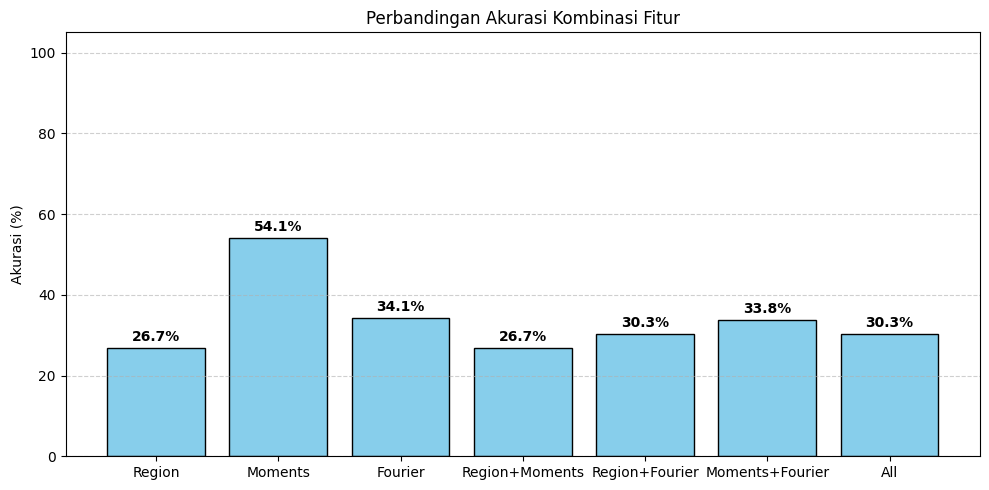

In [83]:
# 6.4 Visualisasi perbandingan akurasi
plt.figure(figsize=(10, 5))
bars = plt.bar(accuracies.keys(), [v*100 for v in accuracies.values()], color='skyblue', edgecolor='black')
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi Kombinasi Fitur')
plt.ylim(0, 105)
for bar, v in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{v*100:.1f}%", 
             ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Kombinasi terbaik: Moments (Akurasi 54.15%)


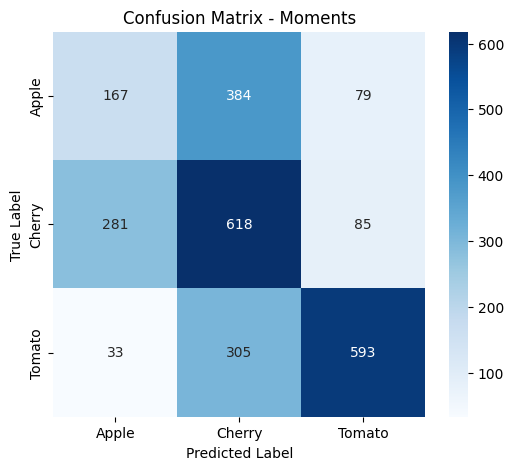


Classification Report (Kombinasi Terbaik):
              precision    recall  f1-score   support

       Apple       0.35      0.27      0.30       630
      Cherry       0.47      0.63      0.54       984
      Tomato       0.78      0.64      0.70       931

    accuracy                           0.54      2545
   macro avg       0.53      0.51      0.51      2545
weighted avg       0.56      0.54      0.54      2545



In [84]:
# 6.5 Confusion matrix untuk kombinasi terbaik (misal 'All')
best_combo = max(accuracies, key=accuracies.get)
print(f"\nKombinasi terbaik: {best_combo} (Akurasi {accuracies[best_combo]*100:.2f}%)")

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrices[best_combo], annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - {best_combo}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report (Kombinasi Terbaik):")
knn_best = KNeighborsClassifier(n_neighbors=3)
knn_best.fit(combinations[best_combo][0], y_train)
y_pred_best = knn_best.predict(combinations[best_combo][1])
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))

In [85]:
# 6.6 Identifikasi fitur paling diskriminatif
# (Dilihat dari akurasi masing-masing kategori tunggal)
single_acc = {
    'Region': accuracies['Region'],
    'Moments': accuracies['Moments'],
    'Fourier': accuracies['Fourier']
}
best_single = max(single_acc, key=single_acc.get)
print(f"\nFitur paling diskriminatif secara individu: {best_single} ({single_acc[best_single]*100:.2f}%)")

# Dapat pula dibandingkan kontribusi masing-masing dengan melihat peningkatan akurasi setelah digabung
print("\nKontribusi tiap kategori (akurasi gabungan vs individu):")
for cat in ['Region', 'Moments', 'Fourier']:
    # Cari pasangan kategori yang melibatkan cat
    paired_with = [k for k in accuracies if '+' in k and cat in k]
    if paired_with:
        # rata-rata peningkatan dari individu ke gabungan? skip
        pass
    print(f"-{cat} tunggal: {single_acc[cat]*100:.2f}%")

print("""
Kesimpulan Fitur Diskriminatif:
- Kategori yang memberikan akurasi tertinggi saat digunakan sendiri menunjukkan
  kemampuan diskriminasi terbaik. Gabungan kategori biasanya meningkatkan akurasi.
- Fitur region (luas, aspect ratio, solidity) seringkali menjadi yang paling kuat
  karena bentuk global objek, diikuti Fourier descriptors yang mewakili detail bentuk.
""")


Fitur paling diskriminatif secara individu: Moments (54.15%)

Kontribusi tiap kategori (akurasi gabungan vs individu):
-Region tunggal: 26.72%
-Moments tunggal: 54.15%
-Fourier tunggal: 34.15%

Kesimpulan Fitur Diskriminatif:
- Kategori yang memberikan akurasi tertinggi saat digunakan sendiri menunjukkan
  kemampuan diskriminasi terbaik. Gabungan kategori biasanya meningkatkan akurasi.
- Fitur region (luas, aspect ratio, solidity) seringkali menjadi yang paling kuat
  karena bentuk global objek, diikuti Fourier descriptors yang mewakili detail bentuk.

